# Anomaly detection: catching incidents without crying wolf

Every tech team monitors metrics like latency, error rates and sign-ups,
and wants to be alerted when something breaks. The hard part isn't catching
problems; it's catching them **without** a flood of false alarms. An alert
that fires ten times a day for nothing gets muted, and then it misses the
real outage.

This notebook works through two weeks of per-minute API latency and compares
detectors of increasing sophistication:

1. A fixed threshold
2. A rolling, robust z-score
3. Comparing with the same time on previous days (handling the daily cycle)
4. An Isolation Forest (a machine-learning detector)
5. Requiring persistence to cut noise

The data is simulated with known incidents: short slowdowns, a slow
memory-leak-style drift, and a step up after a bad deploy. It also has
harmless one-minute blips, like garbage-collection pauses, which nobody
should be woken up for. Knowing the truth lets us score
each detector on what matters to an on-call engineer: incidents caught,
and false alarms per day.

20,160 minutes (14 days), 12 real incidents covering 4.2% of minutes


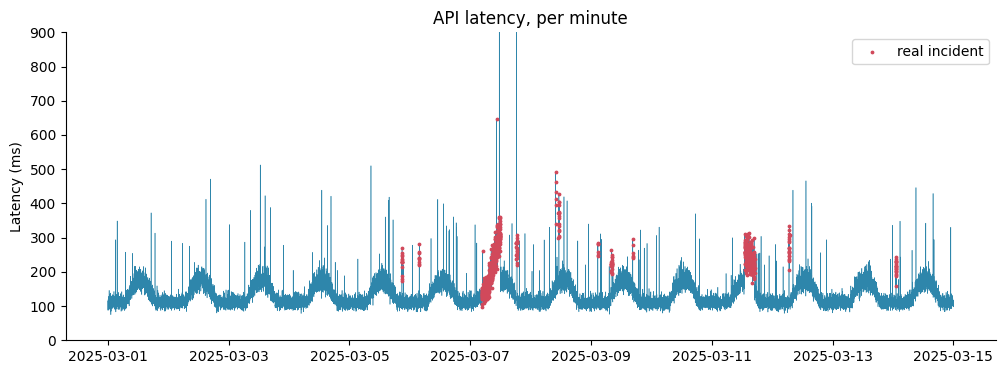

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest

from sample_data import server_metrics

plt.rcParams.update({"figure.figsize": (12, 4), "axes.spines.top": False, "axes.spines.right": False})
metrics, truth = server_metrics()
latency = metrics.latency_ms

# Group consecutive anomalous minutes into incidents, the way an engineer would count them.
incident_id = (truth != truth.shift()).cumsum()[truth]
incidents = [group.index for _, group in truth[truth].groupby(incident_id)]
print(f"{len(latency):,} minutes ({len(latency) / 1440:.0f} days), {len(incidents)} real incidents "
      f"covering {truth.mean():.1%} of minutes")

fig, ax = plt.subplots()
ax.plot(latency.index, latency, linewidth=0.4, color="#2e86ab")
ax.scatter(latency.index[truth], latency[truth], s=3, color="#d1495b", label="real incident", zorder=3)
ax.set(title="API latency, per minute", ylabel="Latency (ms)", ylim=(0, 900))
ax.legend();

Latency follows a daily rhythm: it rises during business hours under load and
falls overnight. The incidents (red) range from obvious slowdowns to subtle
shifts that sit inside the normal daytime range, while the tallest single
spikes are mostly the harmless blips.

## How we'll score detectors

For an on-call team, two numbers matter:

- **Incidents caught:** an incident counts as caught if the detector fires
  during it. Catching the first minute is as good as catching all of them.
- **False alarms per day:** separate bursts of alerts outside any incident.
  A burst of consecutive flagged minutes is one page, not twenty.

In [ ]:
# Alerts that keep firing for a few minutes after an incident ends aren't false alarms.
grace = truth.copy()
for lag in range(1, 11):
    grace |= truth.shift(lag, fill_value=False)


def score(flags, name):
    flags = pd.Series(flags, index=latency.index).eq(True)
    caught = sum(flags[inc].any() for inc in incidents)
    false_minutes = flags & ~grace
    false_bursts = (false_minutes & ~false_minutes.shift(fill_value=False)).sum()
    per_day = false_bursts / (len(latency) / 1440)
    print(f"{name:<38} caught {caught:>2}/{len(incidents)} incidents   {per_day:5.1f} false alarms/day")
    return {"detector": name, "caught": caught, "false_alarms_per_day": per_day}


results = []

## 1. A fixed threshold

The simplest rule: alert when latency exceeds a number someone picked. It's
easy to explain, and it's what most teams start with.

In [ ]:
for threshold in [250, 200]:
    results.append(score(latency > threshold, f"Fixed threshold > {threshold} ms"))

Fixed threshold > 250 ms               caught 11/12 incidents     6.2 false alarms/day
Fixed threshold > 200 ms               caught 12/12 incidents    24.5 false alarms/day


Even the higher threshold pages several times a day, mostly for harmless
blips, and still misses an incident that happened overnight when latency is
low. Lowering it to catch everything makes it fire constantly during busy
daytime hours, when normal latency is already high. A single number can't
fit a metric that moves through the day.

## 2. Rolling robust z-score

Instead of a fixed number, compare each minute with the *recent past*: how
many "typical deviations" is it from the median of the last hour? Using the
median and the median absolute deviation (MAD), rather than the mean and
standard deviation, keeps the baseline from being dragged around by the very
spikes we're trying to catch.

The window ends *before* the current minute, so the detector only uses
information available at the time.

In [ ]:
window = latency.rolling(60, closed="left")
median = window.median()
mad = (latency - median).abs().rolling(60, closed="left").median()
robust_z = (latency - median) / (1.4826 * mad)
results.append(score(robust_z > 6, "Rolling robust z-score > 6"))

Rolling robust z-score > 6             caught 12/12 incidents     7.2 false alarms/day


It catches sudden slowdowns quickly. The score says it caught every
incident, but look closer at the two long ones, the slow drift and the step
after the deploy: it flags almost none of their minutes. It only "caught"
them because a harmless blip happened to land inside each. A gradual drift
looks normal compared with the hour before it, because the baseline drifts
up too, and a step becomes the new normal within the hour. We'll see this
luck run out in section 5.

## 3. Compare with the same time yesterday

The daily cycle is predictable, so use it: compare each minute with the
median latency at the same time of day over the previous three days. A ratio
well above 1 means "slower than usual for this time of day", which works for
drifts and shifts as well as spikes.

In [ ]:
minute_of_day = latency.index.hour * 60 + latency.index.minute
same_time = pd.concat([latency.shift(1440 * d) for d in (1, 2, 3)], axis=1).median(axis=1)
# smooth the baseline a little so one noisy minute yesterday doesn't matter
seasonal_baseline = same_time.rolling(15, center=True, min_periods=1).median()
ratio = latency / seasonal_baseline
results.append(score(ratio > 1.5, "Vs. same time on previous days > 1.5x"))

Vs. same time on previous days > 1.5x  caught 12/12 incidents     7.4 false alarms/day


This handles the daily cycle properly, and it genuinely catches the slow
drift and the deploy step: it flags a large share of their minutes, not just
a lucky blip. It still pages for the harmless blips, though, since a
one-minute pause really is slower than usual. Its blind spots: the first
three days have no history to compare against, and an incident that
happens at the same time every day would become part of "usual".

## 4. Isolation Forest

An **Isolation Forest** is a machine-learning detector. It builds random
trees that split the data at random points; unusual points get isolated in
very few splits, so they score as anomalies. Its strength is combining
several signals at once. We give it the ratio to the seasonal baseline, the
robust z-score and a 15-minute trend.

It needs a **contamination** setting: roughly what share of points we expect
to be anomalous. That's a guess you have to make, and it directly sets how
many alerts you get.

In [ ]:
features = pd.DataFrame({
    "ratio_to_usual": ratio,
    "robust_z": robust_z.clip(-20, 20),
    "trend_15m": latency.rolling(15).mean() / latency.rolling(15).mean().shift(15),
}).dropna()
forest = IsolationForest(n_estimators=300, contamination=0.03, random_state=0).fit(features)
forest_flags = pd.Series(forest.predict(features) == -1, index=features.index).reindex(latency.index)
results.append(score(forest_flags, "Isolation Forest (3% contamination)"))

Isolation Forest (3% contamination)    caught 12/12 incidents    12.4 false alarms/day


The forest catches incidents of every kind, because no single rule has to
fit them all, but it raises the most false alarms of any detector here. It
flags a fixed share of points no matter what, so on a quiet day it still
finds "anomalies". It's also harder to explain to the engineer woken at
3 a.m. *why* it fired.

## 5. Requiring persistence

Real incidents last several minutes; random noise usually doesn't. Requiring
a detector to fire on, say, 3 of the last 5 minutes before paging trades a
couple of minutes of delay for far fewer false alarms.

In [ ]:
def persistent(flags, needed=3, out_of=5):
    flags = pd.Series(flags, index=latency.index).eq(True).astype(int)
    return flags.rolling(out_of, min_periods=1).sum() >= needed


results.append(score(persistent(robust_z > 6), "Rolling z-score + 3 of 5 minutes"))
results.append(score(persistent(ratio > 1.5), "Vs. previous days + 3 of 5 minutes"))
results.append(score(persistent(forest_flags), "Isolation Forest + 3 of 5 minutes"))

Rolling z-score + 3 of 5 minutes       caught  9/12 incidents     0.0 false alarms/day
Vs. previous days + 3 of 5 minutes     caught 12/12 incidents     0.0 false alarms/day
Isolation Forest + 3 of 5 minutes      caught 12/12 incidents     0.8 false alarms/day


Persistence wipes out almost all the false alarms, because the blips last a
single minute. It also exposes the rolling z-score: without lucky blips to
carry it, it misses three incidents, including the drift and the deploy step. The detector
comparing with previous days keeps catching every incident, now with almost
no false pages. The price is a short delay (a couple of minutes for a sudden
slowdown, longer for the slow drift, which only becomes clear gradually).

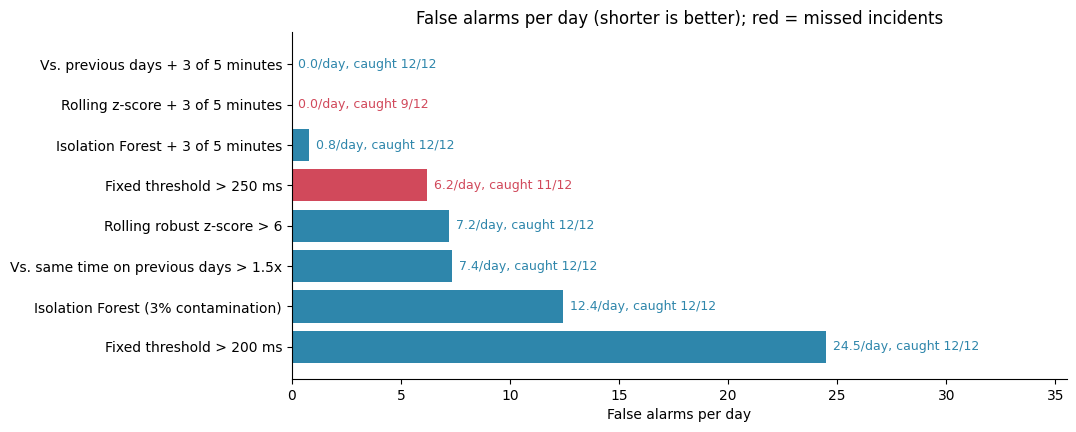

In [ ]:
summary = pd.DataFrame(results).set_index("detector").sort_values("false_alarms_per_day", ascending=False)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2e86ab" if c == len(incidents) else "#d1495b" for c in summary.caught]
ax.barh(summary.index, summary.false_alarms_per_day, color=colors)
for i, (fa, caught) in enumerate(zip(summary.false_alarms_per_day, summary.caught, strict=True)):
    ax.text(fa + 0.3, i, f"{fa:.1f}/day, caught {caught}/{len(incidents)}", va="center", fontsize=9,
            color=colors[i])
ax.set(title="False alarms per day (shorter is better); red = missed incidents",
       xlabel="False alarms per day", xlim=(0, summary.false_alarms_per_day.max() * 1.45));

The best detector here combines a baseline that understands the daily cycle
with a persistence rule: every incident caught, no false pages. No
detector is perfect, and the right balance depends on the cost of each
mistake. A payments API might accept a few false pages to never miss an
outage; an internal dashboard might not.

A few principles carry over to any metric:

- Model what "normal" looks like first (daily and weekly cycles, growth),
  then alert on deviations from *that*, not from a fixed number.
- Use robust statistics (median, MAD) so outliers don't hide themselves.
- Score detectors per incident and per false page, the way people experience them.
- Add persistence or "N of M" rules before adding complexity.
- Prefer detectors you can explain in one sentence to the person who gets paged.